# Proyecto de Machine Learning: Clasificación de GRD en Hospital El Pino

Este notebook refactoriza completamente el flujo de trabajo para abordar el problema correcto: **clasificación multiclase desbalanceada** del código GRD a partir de diagnósticos, procedimientos, edad y sexo.

La variable objetivo se construye extrayendo los **primeros 6 caracteres** de la columna `GRD`.


## 1. Limpieza de datos (Limpiar y filtrar)

Se importan librerías, se fija la semilla, se lee el archivo base `dataset_elpino.csv` tratando `-` como valor faltante, y se eliminan duplicados exactos junto con filas sin información esencial para el modelado.


In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [22]:
DATA_PATH = Path("dataset_elpino.csv")
df_raw = pd.read_csv(DATA_PATH, sep=";", na_values=["-"], low_memory=False)

print(f"Dimensión original: {df_raw.shape}")
display(df_raw.head(3))


Dimensión original: (14561, 68)


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...


In [23]:
diag_cols = [c for c in df_raw.columns if c.startswith("Diag ")]
proc_cols = [c for c in df_raw.columns if c.startswith("Proced ")]
age_col = next(c for c in df_raw.columns if "Edad en" in c)
sex_col = "Sexo (Desc)"
grd_col = "GRD"
main_diag_col = next(c for c in diag_cols if "Principal" in c)

df = df_raw.copy()

duplicados_antes = df.duplicated().sum()
df = df.drop_duplicates()

df["GRD_CODE"] = (
    df[grd_col]
    .astype(str)
    .str.strip()
    .replace("nan", np.nan)
    .str[:6]
)

df[age_col] = pd.to_numeric(df[age_col], errors="coerce")
df[sex_col] = df[sex_col].astype(str).str.strip().replace("nan", np.nan)
df[main_diag_col] = df[main_diag_col].astype(str).str.strip().replace("nan", np.nan)

filas_antes = len(df)
df = df.dropna(subset=["GRD_CODE", age_col, sex_col, main_diag_col])
df = df[df[age_col].between(0, 110)]

print(f"Duplicados exactos eliminados: {duplicados_antes}")
print(f"Filas eliminadas por datos esenciales faltantes o edad inválida: {filas_antes - len(df)}")
print(f"Dimensión tras limpieza: {df.shape}")


Duplicados exactos eliminados: 144
Filas eliminadas por datos esenciales faltantes o edad inválida: 1
Dimensión tras limpieza: (14416, 69)


## 2. Preprocesamiento (Etiquetar datos y asignar valores numéricos)

Se crean variables de conteo (`n_diags`, `n_procs`), se binariza sexo, se codifica el diagnóstico principal con `LabelEncoder`, se arma `X` e `y`, y se realiza una división entrenamiento/prueba 80/20 con `stratify=y` después de remover clases con una sola observación.


In [24]:
df["n_diags"] = df[diag_cols].notna().sum(axis=1)
df["n_procs"] = df[proc_cols].notna().sum(axis=1)

sexo_map = {
    "Mujer": 0,
    "Hombre": 1,
}
df["sexo_bin"] = df[sex_col].map(sexo_map)
df = df.dropna(subset=["sexo_bin"]).copy()

diag_encoder = LabelEncoder()
df["diag_principal_le"] = diag_encoder.fit_transform(df[main_diag_col].astype(str))

class_counts = df["GRD_CODE"].value_counts()
valid_classes = class_counts[class_counts > 1].index
df_model = df[df["GRD_CODE"].isin(valid_classes)].copy()

feature_cols = ["diag_principal_le", "n_diags", "n_procs", age_col, "sexo_bin"]
X = df_model[feature_cols].copy()
y = df_model["GRD_CODE"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Registros para modelado: {len(df_model):,}")
print(f"Clases originales: {df['GRD_CODE'].nunique()}")
print(f"Clases usadas tras remover singletons: {df_model['GRD_CODE'].nunique()}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Registros para modelado: 14,340
Clases originales: 526
Clases usadas tras remover singletons: 450
Train: (11472, 5) | Test: (2868, 5)


## 3. EDA (Análisis Exploratorio)

Se analiza la distribución de edad y se visualiza el fuerte desbalance de clases en los códigos GRD.


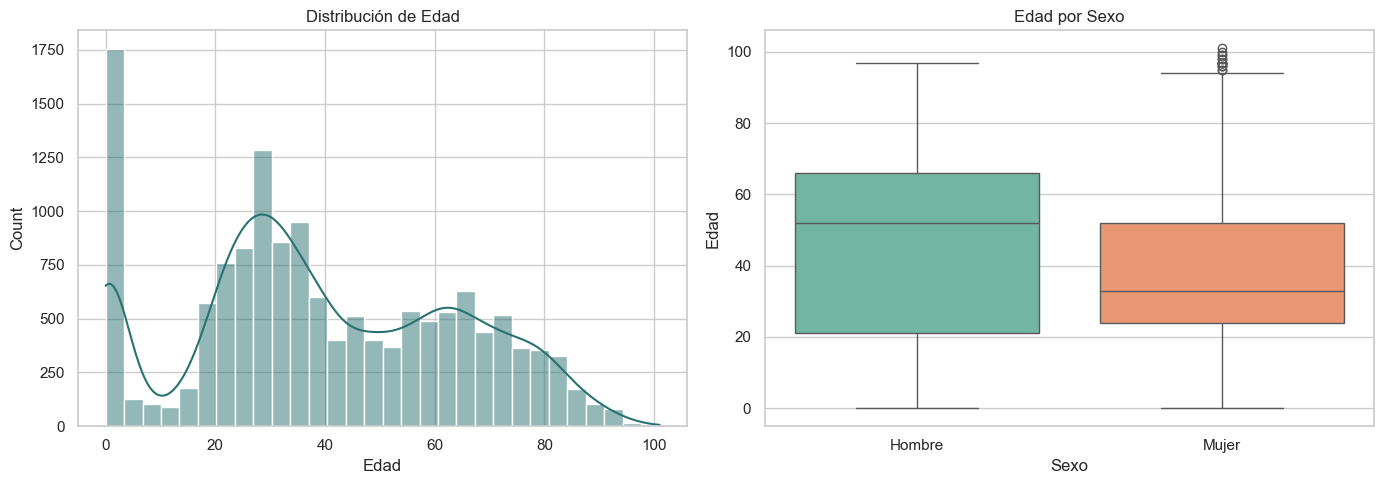

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_model[age_col], bins=30, kde=True, ax=axes[0], color="#287271")
axes[0].set_title("Distribución de Edad")
axes[0].set_xlabel("Edad")

sns.boxplot(data=df_model, x=sex_col, y=age_col, ax=axes[1], palette="Set2")
axes[1].set_title("Edad por Sexo")
axes[1].set_xlabel("Sexo")
axes[1].set_ylabel("Edad")

plt.tight_layout()
plt.show()


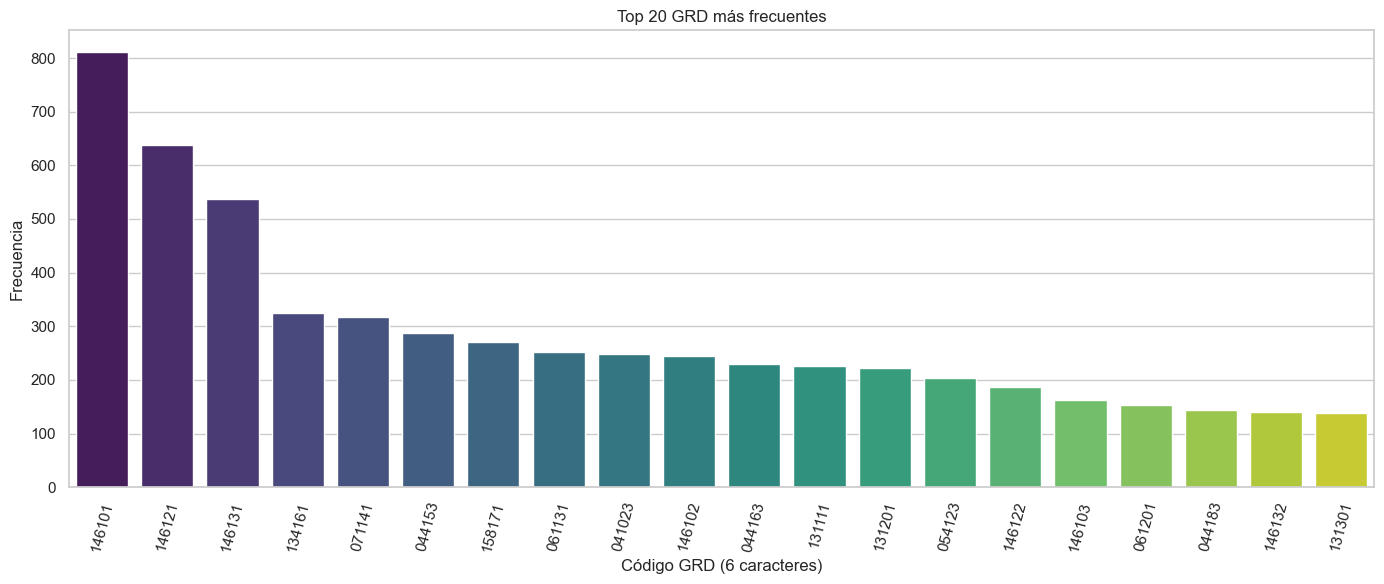

In [26]:
top20_grd = df_model["GRD_CODE"].value_counts().head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=top20_grd.index, y=top20_grd.values, palette="viridis")
plt.title("Top 20 GRD más frecuentes")
plt.xlabel("Código GRD (6 caracteres)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 4. Modelado (Clasificar y hacer predicciones)

Se entrena un `RandomForestClassifier` con `class_weight='balanced'` para abordar el desbalance multiclase.


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=1,
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


## 5. Evaluación del Modelo (Exclusivo para Clasificación)

En esta sección se usan únicamente métricas válidas para clasificación: `Accuracy`, `Precision`, `Recall`, `F1-score`, `classification_report`, matriz de confusión y curvas ROC One-vs-Rest.


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame(
    {
        "Métrica": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1-score (weighted)"],
        "Valor": [accuracy, precision, recall, f1],
    }
)

display(metrics_df)


,Métrica,Valor
0,Accuracy,0.451534
1,Precision (weighted),0.409908
2,Recall (weighted),0.451534
3,F1-score (weighted),0.420973


In [29]:
top10_classes = df_model["GRD_CODE"].value_counts().head(10).index.tolist()
mask_top10 = y_test.isin(top10_classes)

report_top10 = classification_report(
    y_test[mask_top10],
    y_pred[mask_top10],
    labels=top10_classes,
    zero_division=0,
    output_dict=True,
)

report_top10_df = pd.DataFrame(report_top10).transpose()
display(report_top10_df)


,precision,recall,f1-score,support
146101,0.688525,0.777778,0.730435,162.0
146121,0.912621,0.740157,0.817391,127.0
146131,0.851852,0.638889,0.730159,108.0
134161,0.982759,0.876923,0.926829,65.0
071141,1.000000,0.761905,0.864865,63.0
044153,0.822222,0.649123,0.725490,57.0
158171,1.000000,0.722222,0.838710,54.0
061131,1.000000,0.820000,0.901099,50.0
041023,0.617647,0.420000,0.500000,50.0
146102,0.227273,0.102041,0.140845,49.0


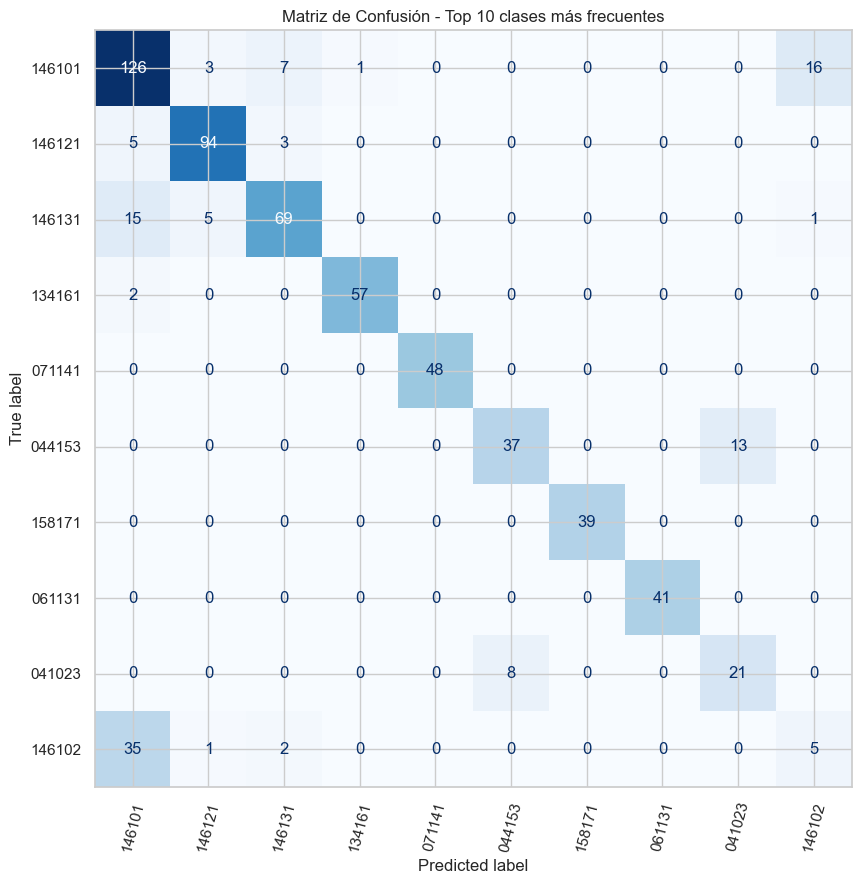

In [30]:
cm = confusion_matrix(y_test[mask_top10], y_pred[mask_top10], labels=top10_classes)

fig, ax = plt.subplots(figsize=(12, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top10_classes)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=75, colorbar=False)
ax.set_title("Matriz de Confusión - Top 10 clases más frecuentes")
plt.tight_layout()
plt.show()


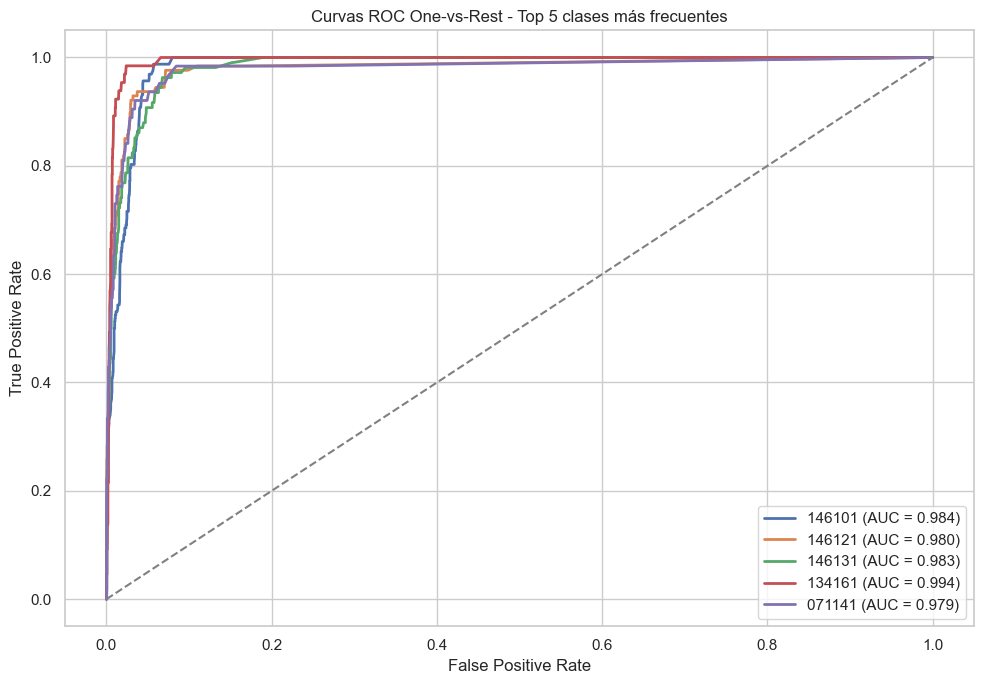

In [31]:
top5_classes = df_model["GRD_CODE"].value_counts().head(5).index.tolist()
proba_df = pd.DataFrame(rf_model.predict_proba(X_test), columns=rf_model.classes_)

plt.figure(figsize=(10, 7))

for cls in top5_classes:
    y_true_binary = (y_test == cls).astype(int)
    if y_true_binary.nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true_binary, proba_df[cls])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curvas ROC One-vs-Rest - Top 5 clases más frecuentes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Visualizaciones del Modelo

Se muestran la importancia de variables y una aproximación de "Loss vs Epochs" usando la evolución del `OOB Score` al incrementar el número de árboles.


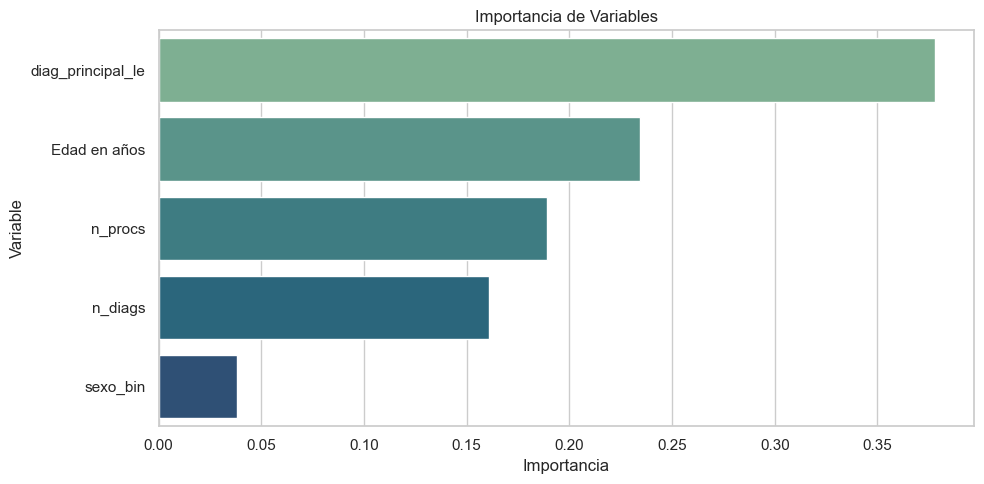

,feature,importance
0,diag_principal_le,0.378089
3,Edad en años,0.234223
2,n_procs,0.188958
1,n_diags,0.160793
4,sexo_bin,0.037937


In [32]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance": rf_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x="importance", y="feature", palette="crest")
plt.title("Importancia de Variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(feature_importance)


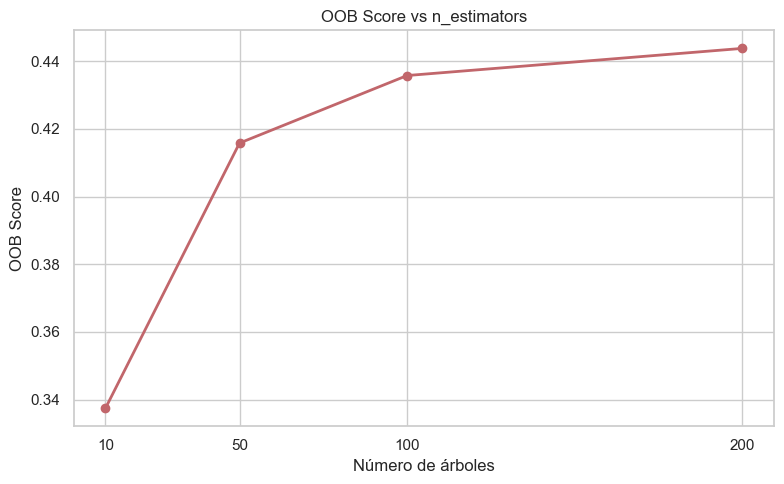

,n_estimators,oob_score
0,10,0.337430
1,50,0.415795
2,100,0.435757
3,200,0.443776


In [33]:
tree_grid = [10, 50, 100, 200]
oob_scores = []

for n_trees in tree_grid:
    rf_oob = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        class_weight="balanced",
        oob_score=True,
        bootstrap=True,
        n_jobs=1,
    )
    rf_oob.fit(X_train, y_train)
    oob_scores.append(rf_oob.oob_score_)

plt.figure(figsize=(8, 5))
plt.plot(tree_grid, oob_scores, marker="o", linewidth=2, color="#c1666b")
plt.title("OOB Score vs n_estimators")
plt.xlabel("Número de árboles")
plt.ylabel("OOB Score")
plt.xticks(tree_grid)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"n_estimators": tree_grid, "oob_score": oob_scores}))


## 7. Discusión y Conclusiones

El problema tratado es multiclase y fuertemente desbalanceado, por lo que la evaluación debe centrarse en métricas de clasificación ponderadas y análisis por clase. El uso de `class_weight='balanced'` ayuda a compensar parcialmente el desbalance, aunque no lo elimina por completo.

La calidad final del modelo depende de la señal contenida en las variables disponibles. Aquí se incorporan variables clínicas resumidas y una codificación del diagnóstico principal, pero aún existe espacio para mejorar con mejor representación de diagnósticos/procedimientos y estrategias más avanzadas para clases raras.


In [34]:
sample_idx = y_test.sample(1, random_state=42).index[0]
sample_features = X_test.loc[[sample_idx]].copy()
sample_real = y_test.loc[sample_idx]
sample_pred = rf_model.predict(sample_features)[0]

print("Ejemplo de Predicción")
display(sample_features)
print(f"GRD real: {sample_real}")
print(f"Predicción del modelo: {sample_pred}")


Ejemplo de Predicción


,diag_principal_le,n_diags,n_procs,Edad en años,sexo_bin
184,1260,7,20,40,0


GRD real: 044203
Predicción del modelo: 044203
